## Fund Analysis Tools

### Setting Up the Environment

In [1]:
import pandas as pd
import plotly.graph_objects as go
from src.fofproject.fund import Fund, input_monthly_returns, subset_of_funds
from src.fofproject.plot import plot_cumulative_returns, plot_fund_correlation_heatmap
from src.fofproject.mvo import minimum_variance_analysis
from loading import load_saved_json, init_funds

# Initialize and load data
funds = input_monthly_returns(r"RETURN DATA.csv")
our_portfolio = ['TAIREN','HAO','LEXINGTON','LIM','FOREST','WT LS','E20','3W GLOBAL','3W CHINA','3W HEALTHCARE','TIMEFOLIO','MONOLITH','PERSEVERANCE','NEO IVY','JH BIOTECH']
our_index = ['MSCI CHINA','TOPIX','S&P 500','MSCI WORLD', 'EUREKAHEDGE']
# funds_to_be_plot = subset_of_funds(funds, ['RDGFF', 'EUREKAHEDGE','MSCI CHINA'])

['ACM GLOBAL', 'BASSWOOD', 'BIOTECHNOLOGY INNOVATION', 'BOYU CAPITAL', 'GOLDEN PINE', 'HAO GREAT', 'LEXINGTON', 'LIM JAPAN', 'NEO IVY', 'PERSEVERANCE']


#### Input Data Via Json

In [ ]:
print(funds['3W CHINA'].total_ann_rtn)

test = load_saved_json(folder_path=r"input\test")
Funds = init_funds(test)
print([f.name for f in Funds])
print(Funds['BASSWOOD'].name)

0.1288154590217292
['ACM GLOBAL', 'BASSWOOD', 'BIOTECHNOLOGY INNOVATION', 'BOYU CAPITAL', 'GOLDEN PINE', 'HAO GREAT', 'LEXINGTON', 'LIM JAPAN', 'NEO IVY', 'PERSEVERANCE']


TypeError: list indices must be integers or slices, not str

### Export Monthly Table

In [ ]:
# Inception column will add a new column for since inception return
funds['HAO'].export_monthly_table(
    benchmark = funds['MSCI WORLD'],
    inception_column = False,
    )

### Plot Cumulative Retrun Graphs

In [8]:

funds_to_be_plot = subset_of_funds(funds, ['NEO IVY', 'MSCI WORLD', '3W CHINA'])
start_month = "2017-12"
end_month = "2018-7"

plot = plot_cumulative_returns(
    funds=funds_to_be_plot,
    title="",
    start_month=start_month,
    end_month=end_month,
    style="excel",
    language="en",
    blur=False,
    aspect_lock=True,
    custom_ticks=False
    )


### Correlation Heat Map

In [2]:
# Correlation heatmap

funds_to_be_plot = funds
start_month = "2019-12"
end_month = "2020-7"

fig, corr_df, overlap_df = plot_fund_correlation_heatmap(funds_to_be_plot, method="pearson", min_overlap=12)

### Summary of a Fund

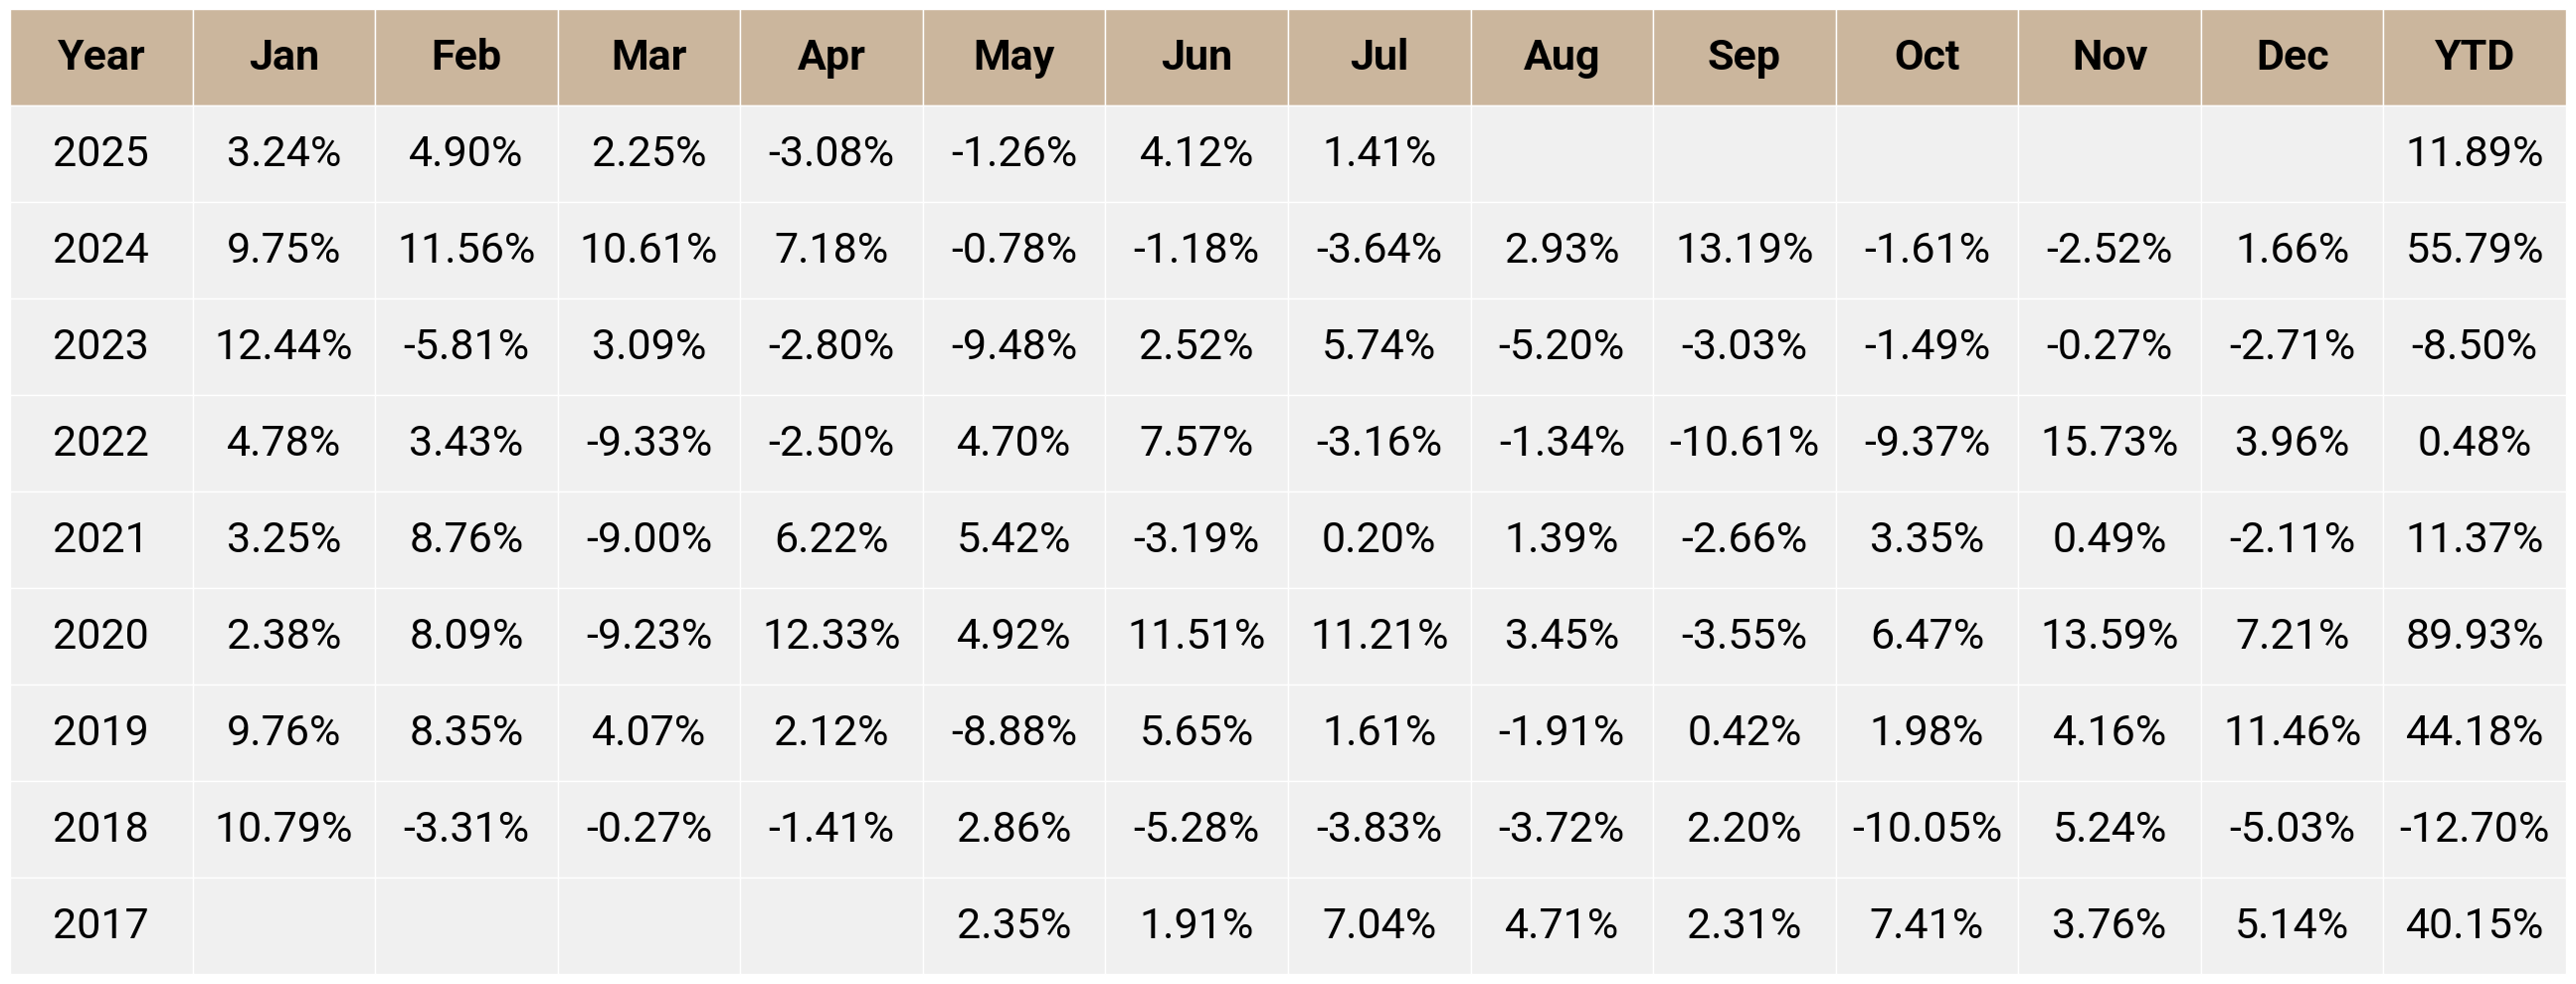

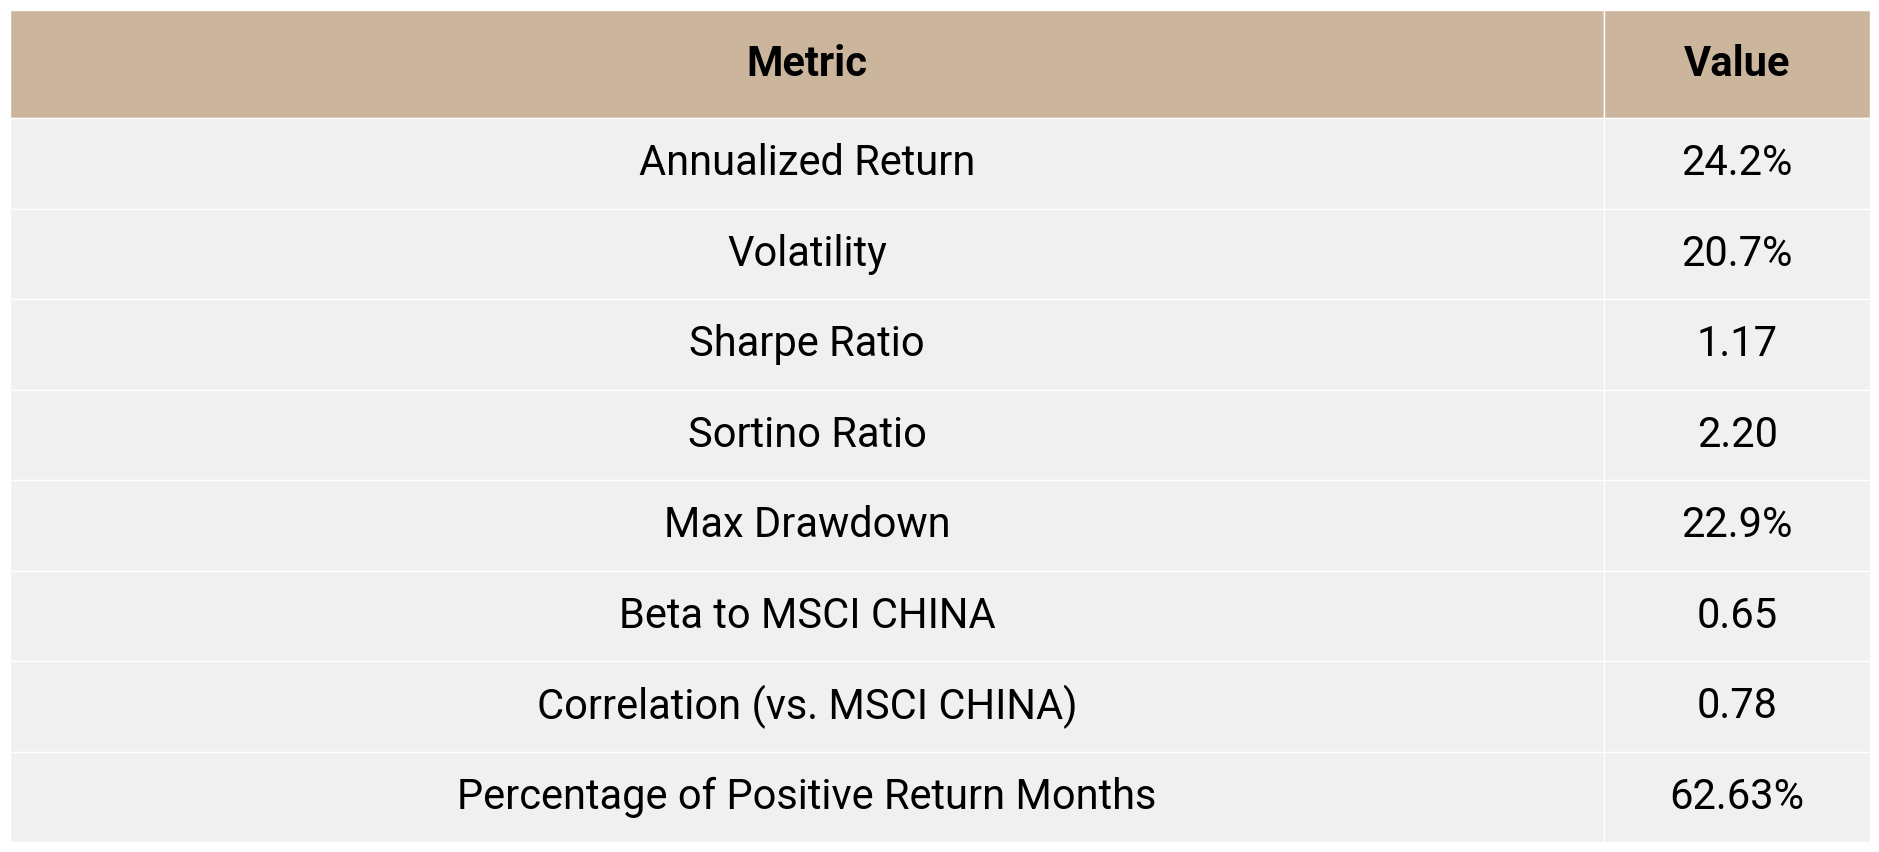

(None,
 None,
 Figure({
     'data': [{'histnorm': 'percent',
               'hovertemplate': '<b>%{x.start:.2%} – %{x.end:.2%}</b><br>%{y:.1f}% of months<extra></extra>',
               'marker': {'color': 'rgba(193,174,148,0.55)', 'line': {'color': 'rgba(193,174,148,0.85)', 'width': 0.8}},
               'name': 'PERSEVERANCE',
               'nbinsx': 24,
               'opacity': 0.95,
               'showlegend': False,
               'type': 'histogram',
               'x': {'bdata': ('qvHSTWIQmD8eFmpN846TPy9uowG8Bb' ... 'JvXwfOib8OvjCZKhilP/8h/fZ14Iw/'),
                     'dtype': 'f8'}},
              {'hovertemplate': '<b>%{x:.2%}</b><br>%{y:.2f}% (smooth)<extra></extra>',
               'line': {'color': '#C1AE94', 'width': 3},
               'mode': 'lines',
               'name': 'KDE',
               'showlegend': False,
               'type': 'scatter',
               'x': {'bdata': ('DeAtkKD4vb9rlOEewsm9v8lIla3jmr' ... 'GRKlvFPwDbN8qZcsU/0gDeAgmKxT8='),
              

In [5]:
funds['PERSEVERANCE'].summary_of_a_fund(funds['MSCI CHINA'],language="en")

#### Quick Investigation

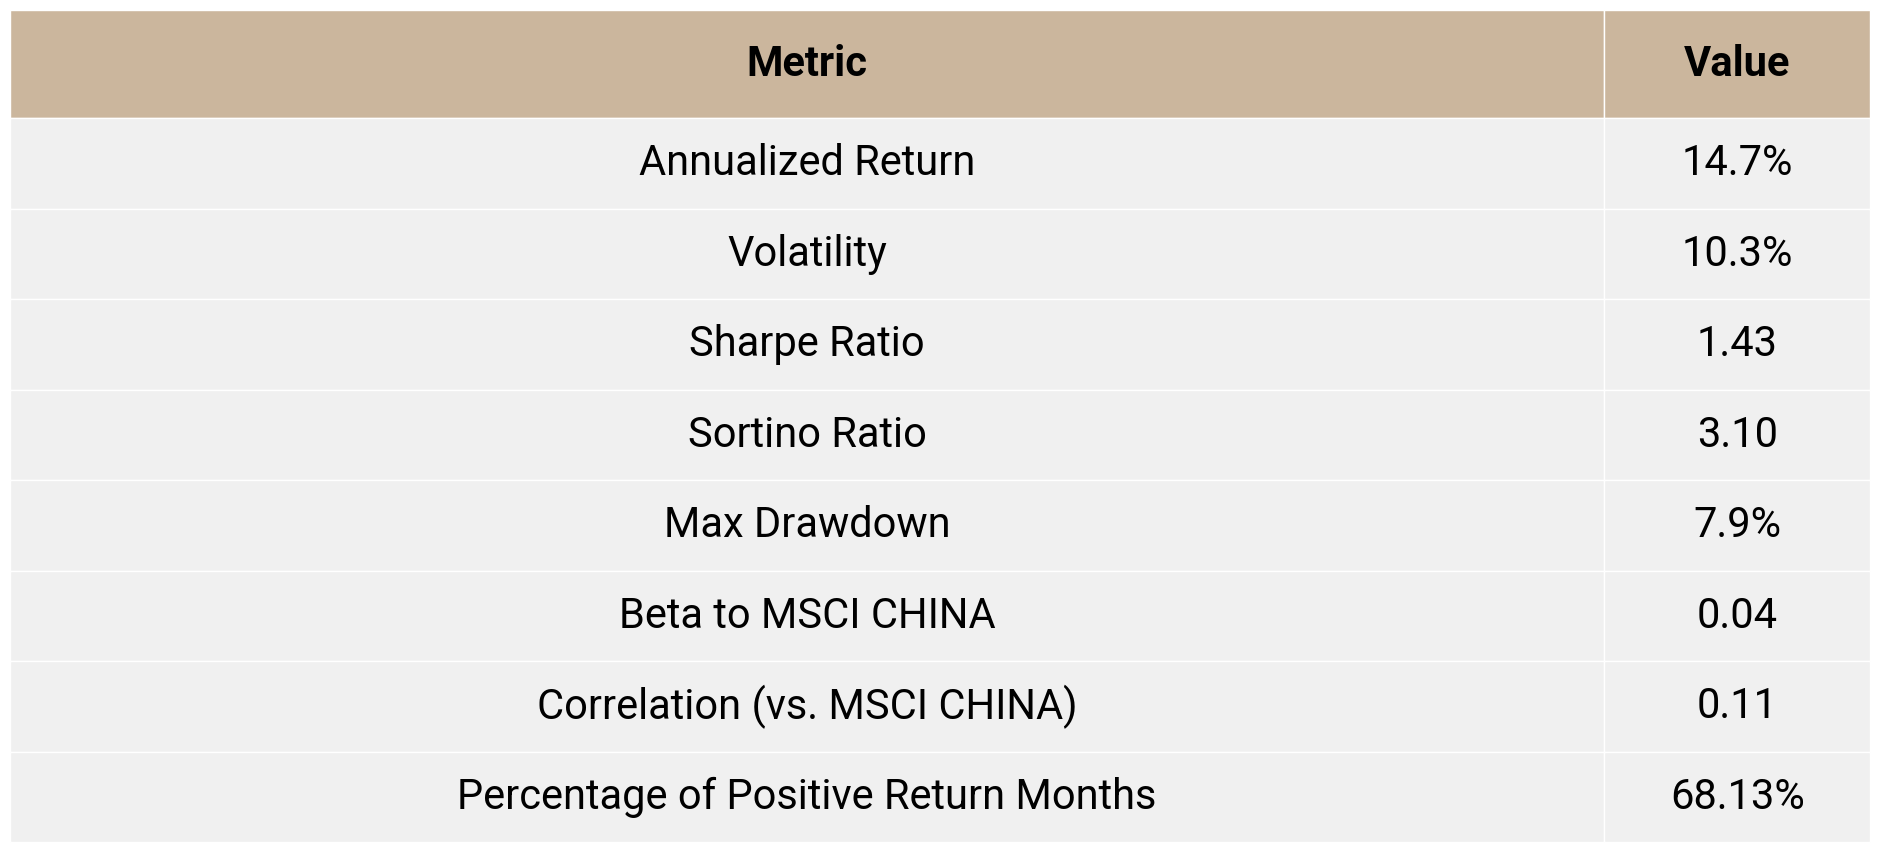

In [ ]:
the_fund_to_investigate = funds['RDGFF']
benchmark_fund = funds['MSCI CHINA']
# The List = ["cagr","vol","sharpe","sortino","mdd","beta","corr","win","best","worst","aum","skew","kurt","turnover"]

fig = the_fund_to_investigate.export_key_metrics_table(
            benchmark_fund=benchmark_fund,
            end_month=the_fund_to_investigate.latest_date,
            language="en",
            metrics=["cagr", "vol", "sharpe", "sortino", "mdd", "beta", "corr", "win"],
            horizontal=False,
        )